# InspiraSTEM — Redes Eléctricas Inteligentes

## Taller práctico — Día 2: análisis de mediciones

En esta sesión exploraremos mediciones de voltaje, frecuencia y potencia para identificar distintos eventos en un sistema eléctrico.


## Objetivos de aprendizaje

Al finalizar la práctica, podrán:

- Visualizar e interpretar mediciones eléctricas.
- Reconocer patrones asociados con cinco condiciones del sistema.
- Convertir señales en características numéricas.
- Entrenar modelos sencillos para clasificar eventos.
- Observar cómo el ruido afecta el análisis.

Analizaremos operación normal, disparo de generación, cortocircuito, incremento de carga y pérdida de carga.


## 1. Sistema de prueba

### Sistema IEEE de 39 buses

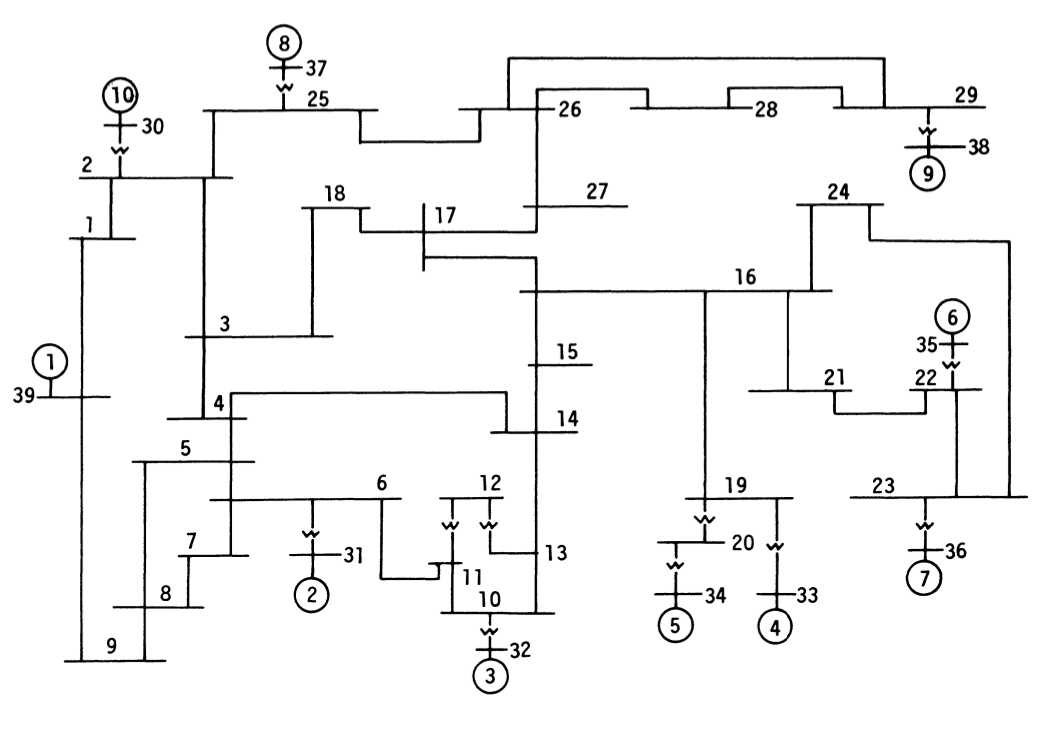

El sistema IEEE de 39 buses, también conocido como el sistema eléctrico de Nueva Inglaterra, es un modelo de referencia ampliamente utilizado para el análisis dinámico y de estabilidad de sistemas eléctricos. Está compuesto por 39 buses, 10 generadores, 19 cargas y 46 líneas de transmisión, y utiliza una potencia base de 100 MVA.

El modelo representa una parte de la red eléctrica de Nueva Inglaterra, con el bus 39 como bus de referencia (*slack bus*). Se utiliza frecuentemente para estudios de flujo de potencia, estabilidad transitoria, estabilidad de pequeña señal, estabilidad de voltaje y evaluación de estrategias de control.

**Referencia:** [PSSim — IEEE 39-bus system](https://github.com/PSSim/PSSim/blob/main/Test_systems/39-bus%20system/Description.md)


## 2. Preparación de los datos

Ejecuten la siguiente celda para importar las librerías y cargar los cinco archivos CSV desde GitHub. Cada fila corresponde a un instante de tiempo y cada columna contiene una medición del sistema.

Los datasets quedarán disponibles con los nombres `normal`, `gen_trip`, `shortckt`, `load_step` y `load_lost`.


In [1]:
# Importar librerías y cargar los archivos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.signal import detrend, find_peaks

base_url = (
    "https://raw.githubusercontent.com/"
    "Alexzelaya/Redes-Electricas-Inteligentes/main/"
    "D%C3%ADa%202/Series_de_tiempo/"
)

normal = pd.read_csv(base_url + "normal.csv")
gen_trip = pd.read_csv(base_url + "gen_trip.csv")
shortckt = pd.read_csv(base_url + "shortckt.csv")
load_step = pd.read_csv(base_url + "load_step.csv")
load_lost = pd.read_csv(base_url + "load_lost.csv")

print("Los archivos fueron cargados correctamente.")
print(f"Número de muestras por evento: {len(normal)}")
print(f"Número de columnas: {len(normal.columns)}")


Los archivos fueron cargados correctamente.
Número de muestras por evento: 76
Número de columnas: 70


## 3. Visualización interactiva de las señales

La función `plot_signals()` permite graficar una señal, una lista de señales o un grupo completo. Los gráficos son interactivos: pueden hacer zoom, consultar valores y ocultar curvas desde la leyenda.

El argumento `signals` acepta:

- Una señal: `"f_gen_01"`.
- Una lista: `["V_bus_01", "V_bus_15"]`.
- `"all_voltage"`: todos los voltajes.
- `"all_frequency"`: todas las frecuencias.
- `"all_active_power"`: todas las potencias activas.
- `"all_reactive_power"`: todas las potencias reactivas.
- `"all_power"`: todas las potencias activas y reactivas.
- `"all"`: todas las mediciones, excepto el tiempo.

Con `separate=False`, las señales se superponen. Con `separate=True`, cada señal aparece en su propia subgráfica.


In [2]:
def select_signals(data, signals):
    """Convierte nombres u opciones de grupo en una lista de columnas."""

    if "time" not in data.columns:
        raise ValueError("El dataset no contiene la columna 'time'.")

    if isinstance(signals, str):
        signals = [signals]

    prefixes = {
        "all_voltage": ("V_bus_",),
        "all_frequency": ("f_gen_",),
        "all_active_power": ("P_gen_",),
        "all_reactive_power": ("Q_gen_",),
        "all_power": ("P_gen_", "Q_gen_"),
    }

    selected = []

    for signal in signals:
        if signal == "all":
            selected.extend(column for column in data.columns if column != "time")
        elif signal in prefixes:
            selected.extend(
                column for column in data.columns
                if column.startswith(prefixes[signal])
            )
        elif signal in data.columns:
            selected.append(signal)
        else:
            raise ValueError(f"La señal u opción '{signal}' no existe.")

    selected = list(dict.fromkeys(selected))

    if not selected:
        raise ValueError("No se encontraron señales para analizar.")

    return selected


def plot_signals(data, signals, title="Señales del sistema", separate=False):
    """Grafica interactivamente una o varias señales."""

    selected_signals = select_signals(data, signals)

    if separate:
        fig = make_subplots(
            rows=len(selected_signals),
            cols=1,
            shared_xaxes=True,
            subplot_titles=selected_signals,
            vertical_spacing=min(0.05, 0.5 / len(selected_signals))
        )

        for row, signal in enumerate(selected_signals, start=1):
            fig.add_trace(
                go.Scatter(
                    x=data["time"],
                    y=data[signal],
                    mode="lines",
                    name=signal
                ),
                row=row,
                col=1
            )
            fig.update_yaxes(title_text=signal, row=row, col=1)

        fig.update_xaxes(
            title_text="Tiempo [s]",
            row=len(selected_signals),
            col=1
        )
        fig.update_layout(
            title=title,
            height=max(500, 250 * len(selected_signals)),
            template="plotly_white",
            hovermode="x unified",
            showlegend=False
        )
    else:
        fig = go.Figure()

        for signal in selected_signals:
            fig.add_trace(
                go.Scatter(
                    x=data["time"],
                    y=data[signal],
                    mode="lines",
                    name=signal
                )
            )

        fig.update_layout(
            title=title,
            xaxis_title="Tiempo [s]",
            yaxis_title="Valor",
            template="plotly_white",
            hovermode="x unified",
            height=550,
            legend_title="Señales"
        )

    fig.show()


### 3.1 Graficar una señal

Indiquen primero el dataset y después el nombre de la medición.


In [3]:
plot_signals(
    gen_trip,
    "f_gen_01",
    title="Frecuencia del generador 1"
)


### 3.2 Comparar varias señales

Para comparar mediciones, coloquen sus nombres dentro de una lista. Si tienen la misma unidad, pueden superponerlas. Para señales con unidades o escalas distintas, utilicen `separate=True`.


In [4]:
plot_signals(
    shortckt,
    ["V_bus_01", "V_bus_15", "V_bus_39"],
    title="Voltajes seleccionados durante un cortocircuito"
)


In [5]:
plot_signals(
    load_step,
    ["V_bus_01", "f_gen_01", "P_gen_01_MW", "Q_gen_01_Mvar"],
    title="Respuesta ante un incremento de carga",
    separate=True
)


### 3.3 Graficar grupos completos

Las opciones de grupo evitan escribir individualmente los nombres de todas las columnas.

```python
plot_signals(shortckt, "all_voltage", title="Voltajes durante un cortocircuito")
plot_signals(gen_trip, "all_frequency", title="Frecuencias durante un disparo")
plot_signals(load_step, "all_power", title="Potencias durante un incremento de carga")
```

Al graficar muchas señales, pueden hacer clic en la leyenda para ocultarlas o mostrarlas.


In [6]:
plot_signals(
    gen_trip,
    "all_frequency",
    title="Frecuencias de las máquinas: disparo de generación"
)


### 3.4 Exploración libre

Modifiquen la siguiente celda para explorar otras mediciones o eventos.

**Datasets:** `normal`, `gen_trip`, `shortckt`, `load_step` y `load_lost`.

**Señales:** `V_bus_01` a `V_bus_39`, `f_gen_01` a `f_gen_10`, `P_gen_01_MW` a `P_gen_10_MW` y `Q_gen_01_Mvar` a `Q_gen_10_Mvar`.


In [7]:
# Cambien el dataset, las señales y el título
plot_signals(
    normal,
    ["V_bus_01", "f_gen_01"],
    title="Exploración de señales",
    separate=True
)


## Actividad 1: Identificación visual de eventos

Cada grupo analizará uno de los siguientes eventos:

- **Grupo 1:** disparo de generación.
- **Grupos 2 y 3:** cortocircuito.
- **Grupo 4:** incremento de carga.
- **Grupo 5:** pérdida de carga.

### Instrucciones

1. Grafiquen los voltajes, las frecuencias y las potencias activa y reactiva.
2. Identifiquen los cambios que permitirían reconocer el evento.
3. Determinen cuáles gráficas contienen la información más útil.

Consideren:

- ¿Qué variables cambian?
- ¿Aumentan o disminuyen?
- ¿El cambio es brusco, gradual u oscilatorio?
- ¿Qué características distinguen este evento de los demás?

Si tienen tiempo y están seguros de su respuesta, seleccionen un segundo evento y comparen sus principales diferencias.

### Presentación

Expliquen brevemente las gráficas más relevantes, las características observadas y cómo identificarían el evento utilizando únicamente las mediciones.

**Tiempo de análisis:** 15 minutos  
**Tiempo de presentación:** 3 minutos por grupo


## 4. Análisis numérico de las señales

La inspección visual ayuda a reconocer patrones, pero también necesitamos representar cada respuesta mediante valores numéricos. La función `analyze_signals()` genera una fila por señal con las siguientes características:

- Valor mínimo y el instante en que ocurre.
- Valor máximo y el instante en que ocurre.
- Rango de la señal: máximo menos mínimo.
- Número de picos detectados.
- Periodo y frecuencia aproximados de la oscilación.

El parámetro `start_time` permite analizar únicamente la respuesta posterior al evento. En estos ejemplos utilizaremos `start_time=1.0` porque el evento se aplica en $t=1$ s.

> **Nota:** si no se detectan al menos dos picos, el periodo y la frecuencia de oscilación aparecerán como `NaN`. Esto significa que no hay información suficiente para estimarlos; no necesariamente indica un error.


In [8]:
def analyze_signals(
    data,
    signals,
    start_time=None,
    prominence=None,
    min_peak_distance=0.1
):
    """Calcula características numéricas de una o varias señales."""

    selected_signals = select_signals(data, signals)

    if start_time is None:
        analysis_data = data.copy()
    else:
        analysis_data = data[data["time"] >= start_time].copy()

    if analysis_data.empty:
        raise ValueError("No existen datos en la ventana seleccionada.")

    time = analysis_data["time"].to_numpy(dtype=float)

    if len(time) < 3:
        raise ValueError("No hay suficientes muestras para realizar el análisis.")

    dt = np.median(np.diff(time))

    if dt <= 0:
        raise ValueError("La columna de tiempo debe estar ordenada.")

    minimum_peak_samples = max(1, int(min_peak_distance / dt))
    results = []

    for signal in selected_signals:
        values = analysis_data[signal].to_numpy(dtype=float)
        valid = np.isfinite(time) & np.isfinite(values)
        signal_time = time[valid]
        signal_values = values[valid]

        if len(signal_values) < 3:
            continue

        minimum_index = np.argmin(signal_values)
        maximum_index = np.argmax(signal_values)

        minimum_value = signal_values[minimum_index]
        maximum_value = signal_values[maximum_index]
        minimum_time = signal_time[minimum_index]
        maximum_time = signal_time[maximum_index]
        signal_range = maximum_value - minimum_value

        detrended_signal = detrend(signal_values)

        if prominence is None:
            signal_prominence = 0.10 * np.ptp(detrended_signal)
        else:
            signal_prominence = prominence

        oscillation_period = np.nan
        oscillation_frequency = np.nan
        number_of_peaks = 0

        if signal_prominence > 0:
            peaks, _ = find_peaks(
                detrended_signal,
                prominence=signal_prominence,
                distance=minimum_peak_samples
            )
            number_of_peaks = len(peaks)

            if number_of_peaks >= 2:
                peak_times = signal_time[peaks]
                oscillation_period = np.median(np.diff(peak_times))

                if oscillation_period > 0:
                    oscillation_frequency = 1 / oscillation_period

        results.append({
            "Señal": signal,
            "Valor mínimo": minimum_value,
            "Tiempo del mínimo [s]": minimum_time,
            "Valor máximo": maximum_value,
            "Tiempo del máximo [s]": maximum_time,
            "Rango": signal_range,
            "Picos detectados": number_of_peaks,
            "Periodo de oscilación [s]": oscillation_period,
            "Frecuencia de oscilación [Hz]": oscillation_frequency
        })

    return pd.DataFrame(results)


### 4.1 Analizar una señal

El resultado contiene una sola fila, correspondiente a la señal seleccionada.


In [9]:
resultados_una_frecuencia = analyze_signals(
    gen_trip,
    "f_gen_01",
    start_time=1.0
)

resultados_una_frecuencia


,Señal,Valor mínimo,Tiempo del mínimo [s],Valor máximo,Tiempo del máximo [s],Rango,Picos detectados,Periodo de oscilación [s],Frecuencia de oscilación [Hz]
0,f_gen_01,58.1437,9.377991,59.999993,1.0,1.856293,0,NaN,NaN


### 4.2 Analizar un grupo completo

Las mismas opciones utilizadas para graficar también funcionan en el análisis numérico.


In [10]:
resultados_frecuencias = analyze_signals(
    gen_trip,
    "all_frequency",
    start_time=1.0
)

resultados_frecuencias


,Señal,Valor mínimo,Tiempo del mínimo [s],Valor máximo,Tiempo del máximo [s],Rango,Picos detectados,Periodo de oscilación [s],Frecuencia de oscilación [Hz]
0,f_gen_01,58.143700,9.377991,59.999993,1.0,1.856293,0,NaN,NaN
1,f_gen_02,58.125297,9.406910,59.999993,1.0,1.874696,1,NaN,NaN
2,f_gen_03,59.999993,1.000000,59.999993,1.0,0.000000,0,NaN,NaN
3,f_gen_04,58.141023,9.181851,59.999994,1.0,1.858971,0,NaN,NaN
4,f_gen_05,58.132975,9.072468,59.999994,1.0,1.867020,0,NaN,NaN
5,f_gen_06,58.137004,9.291234,59.999994,1.0,1.862990,0,NaN,NaN
6,f_gen_07,58.137828,9.291234,59.999994,1.0,1.862166,0,NaN,NaN
7,f_gen_08,58.145010,9.349072,59.999993,1.0,1.854983,0,NaN,NaN
8,f_gen_09,58.134143,9.127159,59.999994,1.0,1.865850,0,NaN,NaN
9,f_gen_10,58.142815,8.685935,59.999991,1.0,1.857176,0,NaN,NaN


### 4.3 Analizar una selección de variables

También pueden combinar voltajes, frecuencias y potencias en una misma tabla.


In [11]:
resultados_seleccionados = analyze_signals(
    shortckt,
    ["V_bus_01", "V_bus_15", "f_gen_01", "P_gen_01_MW"],
    start_time=1.0
)

resultados_seleccionados


,Señal,Valor mínimo,Tiempo del mínimo [s],Valor máximo,Tiempo del máximo [s],Rango,Picos detectados,Periodo de oscilación [s],Frecuencia de oscilación [Hz]
0,V_bus_01,0.897109,1.431144,1.047013,3.195077,0.149904,19,1.068149,0.936199
1,V_bus_15,0.535656,1.083333,1.030023,3.089323,0.494367,10,1.101099,0.908183
2,f_gen_01,59.681069,3.787225,60.707538,1.332267,1.026469,14,1.055815,0.947136
3,P_gen_01_MW,46.132978,1.000006,425.095928,2.548579,378.962950,19,0.572440,1.746908


## Actividad 2: Análisis numérico

Ahora que conocen las características visuales de cada evento, conviertan sus observaciones en valores numéricos.

### Instrucciones

1. Utilicen el mismo evento asignado en la Actividad 1.
2. Seleccionen las señales que consideren más relevantes.
3. Utilicen `analyze_signals()` para obtener sus valores mínimos, máximos, rangos y, cuando corresponda, sus periodos de oscilación.
4. Organicen los resultados en una tabla y seleccionen únicamente las características útiles para reconocer el evento.
5. Expliquen qué valores permitirían diferenciar su evento de los demás.

Si tienen tiempo, analicen un segundo evento y comparen ambas tablas.

### Presentación

Presenten la tabla, destaquen las características más importantes y expliquen cómo podrían utilizarse para identificar automáticamente el evento.

**Tiempo de análisis:** 10 minutos  
**Tiempo de presentación:** 3 minutos por grupo

### Pregunta de transición

**¿Qué pasaría si tuvieran que analizar cientos o miles de eventos?**


## 5. Clasificación automática de eventos

Analizar señales manualmente funciona para pocos casos. Para analizar cientos de eventos, entrenaremos modelos que relacionen las características numéricas con el tipo de evento.

Usaremos dos modelos:

- **Árbol de decisión:** sencillo y fácil de interpretar.
- **Random Forest:** combina varios árboles y suele ser más robusto.


### 5.1 Cargar el dataset de características

Cada fila representa una vista de una simulación. Las primeras ocho columnas identifican la simulación y las mediciones; las columnas 9–42 contienen las características utilizadas por los modelos.

| Columnas | Contenido |
|---|---|
| 1–8 | Identificación, evento y puntos de medición |
| 9–20 | Características de dos voltajes |
| 21–34 | Características de dos frecuencias |
| 35–38 | Características de potencia activa |
| 39–42 | Características de potencia reactiva |


In [12]:
features_url = (
    "https://raw.githubusercontent.com/Alexzelaya/"
    "Redes-Electricas-Inteligentes/main/"
    "D%C3%ADa%202/dataset_eventos.csv"
)

dataset = pd.read_csv(features_url)

print("Dimensiones:", dataset.shape)
print("Eventos:", dataset["event_type"].unique())
dataset.head()


Dimensiones: (1600, 42)
Eventos: ['generator_outage' 'load_increase' 'load_decrease' 'fault']


,simulation_id,event_type,view_id,V_bus_1,V_bus_2,f_gen_1,f_gen_2,PQ_gen,V1_pre,V1_min,...,t_nadir_f2,settling_time_f2,P_pre,P_min,P_max,delta_P,Q_pre,Q_min,Q_max,delta_Q
0,generator_outage_G01,generator_outage,1,1,2,1,2,1,1.026896,1.004570,...,7.668895,20.397564,247.351645,0.0,247.351919,-247.351645,178.51391,0.0,178.514465,-178.51391
1,generator_outage_G01,generator_outage,2,18,25,1,7,1,0.993422,0.960778,...,7.698646,20.397564,247.351645,0.0,247.351919,-247.351645,178.51391,0.0,178.514465,-178.51391
2,generator_outage_G01,generator_outage,3,9,25,2,5,1,1.020208,1.006531,...,7.668895,20.574371,247.351645,0.0,247.351919,-247.351645,178.51391,0.0,178.514465,-178.51391
3,generator_outage_G01,generator_outage,4,2,31,3,4,1,1.020017,0.971109,...,7.850742,20.485968,247.351645,0.0,247.351919,-247.351645,178.51391,0.0,178.514465,-178.51391
4,generator_outage_G01,generator_outage,5,21,33,3,9,1,0.997580,0.974046,...,7.728397,20.397564,247.351645,0.0,247.351919,-247.351645,178.51391,0.0,178.514465,-178.51391


### 5.2 Dividir los datos

Separaremos las **simulaciones**, no las filas: 60 % para entrenamiento, 20 % para validación y 20 % para prueba. Así, las vistas de una misma simulación permanecen juntas y la evaluación se realiza con eventos nuevos.


In [13]:
from sklearn.model_selection import train_test_split

# Una fila por simulación
simulaciones = dataset[["simulation_id", "event_type"]].drop_duplicates()

# 60 % entrenamiento, 20 % validación y 20 % prueba
sim_train, sim_temp = train_test_split(
    simulaciones,
    test_size=0.40,
    random_state=42,
    stratify=simulaciones["event_type"]
)

sim_validation, sim_test = train_test_split(
    sim_temp,
    test_size=0.50,
    random_state=42,
    stratify=sim_temp["event_type"]
)

train_data = dataset[dataset["simulation_id"].isin(sim_train["simulation_id"])]
validation_data = dataset[dataset["simulation_id"].isin(sim_validation["simulation_id"])]
test_data = dataset[dataset["simulation_id"].isin(sim_test["simulation_id"])]

feature_columns = dataset.columns[8:]

X_train = train_data[feature_columns].replace([np.inf, -np.inf], np.nan)
X_validation = validation_data[feature_columns].replace([np.inf, -np.inf], np.nan)
X_test = test_data[feature_columns].replace([np.inf, -np.inf], np.nan)

y_train = train_data["event_type"]
y_validation = validation_data["event_type"]
y_test = test_data["event_type"]

pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "Simulaciones": [len(sim_train), len(sim_validation), len(sim_test)],
    "Registros": [len(train_data), len(validation_data), len(test_data)]
})


,Conjunto,Simulaciones,Registros
0,Entrenamiento,12,960
1,Validación,4,320
2,Prueba,4,320


### 5.3 Entrenar y comparar dos modelos

Los modelos aprenderán con el conjunto de entrenamiento. Utilizaremos la validación para compararlos sin tocar todavía los datos de prueba.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Árbol de decisión": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

validation_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_validation)
    validation_results.append({
        "Modelo": name,
        "Exactitud de validación": accuracy_score(y_validation, predictions)
    })

validation_results = pd.DataFrame(validation_results).sort_values(
    "Exactitud de validación",
    ascending=False
)

validation_results.style.format({"Exactitud de validación": "{:.2%}"})


,Modelo,Exactitud de validación
1,Random Forest,75.00%
0,Árbol de decisión,50.00%


### 5.4 Evaluar el mejor modelo

Seleccionaremos el modelo con mayor exactitud de validación, lo entrenaremos nuevamente usando entrenamiento y validación, y lo evaluaremos una sola vez con los datos de prueba.


Modelo seleccionado: Random Forest
Exactitud de prueba: 75.00%


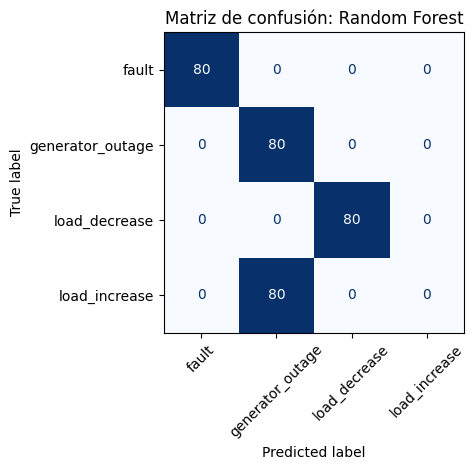

In [15]:
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = validation_results.iloc[0]["Modelo"]
final_model = clone(models[best_model_name])

X_final_train = pd.concat([X_train, X_validation])
y_final_train = pd.concat([y_train, y_validation])

final_model.fit(X_final_train, y_final_train)
test_predictions = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Modelo seleccionado:", best_model_name)
print(f"Exactitud de prueba: {test_accuracy:.2%}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)
plt.title(f"Matriz de confusión: {best_model_name}")
plt.tight_layout()
plt.show()


## Actividad 3: Interpretación de la clasificación

Observen la tabla y la matriz de confusión:

1. ¿Cuál modelo obtuvo la mejor exactitud de validación?
2. ¿Qué eventos fueron identificados correctamente?
3. ¿Cuáles fueron confundidos y por qué podrían parecerse?

**Tiempo:** 7 minutos


## 6. Análisis de señales con ruido

Las mediciones reales contienen pequeñas variaciones producidas por sensores, comunicaciones e interferencias. Este **ruido** puede dificultar la inspección visual y el cálculo de características.

Agregaremos ruido gaussiano, es decir, variaciones aleatorias alrededor de cero:

$$x_{\mathrm{ruido}}(t)=x(t)+n(t)$$

donde $n(t)$ representa el ruido y su desviación estándar controla la intensidad.


In [16]:
def add_gaussian_noise(data, noise_levels=None, seed=42):
    """Agrega ruido gaussiano a una copia de las mediciones."""

    if noise_levels is None:
        noise_levels = {
            "voltage": 0.02,        # pu
            "frequency": 0.02,      # Hz
            "active_power": 0.5,    # MW
            "reactive_power": 0.5   # Mvar
        }

    noisy_data = data.copy()
    rng = np.random.default_rng(seed)

    for column in noisy_data.columns:
        if column == "time":
            continue

        if column.startswith("V_bus_"):
            sigma = noise_levels["voltage"]
        elif column.startswith("f_gen_"):
            sigma = noise_levels["frequency"]
        elif column.startswith("P_gen_"):
            sigma = noise_levels["active_power"]
        elif column.startswith("Q_gen_"):
            sigma = noise_levels["reactive_power"]
        else:
            continue

        noisy_data[column] += rng.normal(
            loc=0,
            scale=sigma,
            size=len(noisy_data)
        )

    return noisy_data


### 6.1 Crear los datasets con ruido

Crearemos una copia de cada dataset para conservar intactos los datos originales. La semilla `seed` permite generar los mismos valores aleatorios cada vez que se ejecuta la notebook.


In [17]:
normal_noisy = add_gaussian_noise(normal, seed=1)
gen_trip_noisy = add_gaussian_noise(gen_trip, seed=2)
shortckt_noisy = add_gaussian_noise(shortckt, seed=3)
load_step_noisy = add_gaussian_noise(load_step, seed=4)
load_lost_noisy = add_gaussian_noise(load_lost, seed=5)

print("Se crearon correctamente los datasets con ruido.")


Se crearon correctamente los datasets con ruido.


### 6.2 Comparar las señales

Superpondremos la medición original y su versión con ruido para observar qué patrones permanecen visibles.


In [18]:
def compare_clean_noisy(
    clean_data,
    noisy_data,
    signal,
    title="Comparación de señales"
):
    """Compara una señal original con su versión con ruido."""

    if signal not in clean_data.columns:
        raise ValueError(f"La señal '{signal}' no existe en el dataset.")

    if signal not in noisy_data.columns:
        raise ValueError(f"La señal '{signal}' no existe en el dataset con ruido.")

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=clean_data["time"],
        y=clean_data[signal],
        mode="lines",
        name="Sin ruido",
        line=dict(color="royalblue", width=2)
    ))

    fig.add_trace(go.Scatter(
        x=noisy_data["time"],
        y=noisy_data[signal],
        mode="lines",
        name="Con ruido",
        line=dict(color="tomato", width=2)
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Tiempo [s]",
        yaxis_title=signal,
        template="plotly_white",
        hovermode="x unified",
        height=450
    )

    fig.show()


### 6.3 Ejemplos

Comparemos señales con y sin ruido en diferentes condiciones.


In [19]:
compare_clean_noisy(
    gen_trip,
    gen_trip_noisy,
    "f_gen_01",
    title="Frecuencia durante un disparo de generación"
)


In [20]:
compare_clean_noisy(
    shortckt,
    shortckt_noisy,
    "V_bus_15",
    title="Voltaje durante un cortocircuito"
)


In [21]:
compare_clean_noisy(
    normal,
    normal_noisy,
    "V_bus_15",
    title="Voltaje durante la operación normal"
)


## Actividad 4: El efecto del ruido

Seleccionen un evento y una señal relevante:

1. Comparen la señal con y sin ruido.
2. Calculen sus mínimos y máximos con `analyze_signals()`.
3. Determinen qué patrones permanecen visibles y cuáles son más difíciles de identificar.
4. Discutan cómo el ruido podría afectar una clasificación automática.

> Un modelo puede ser más robusto si durante el entrenamiento observa ejemplos con niveles de ruido similares a los encontrados en mediciones reales.

**Tiempo:** 10 minutos  
**Presentación:** 2 minutos por grupo


## 7. Clasificación con datos ruidosos

¿Qué tan robusto es el clasificador? Primero aumentaremos gradualmente el ruido y observaremos cuándo disminuye su exactitud. Después lo entrenaremos con varios niveles de ruido y repetiremos la prueba.

> Para simplificar la práctica, el ruido se agrega a las características que recibe el clasificador. En una aplicación real, se agregaría a las señales y después se volverían a calcular las características.


### 7.1 Función para agregar ruido

El ruido se adapta a la escala de cada característica. Por ejemplo, `0.50` representa un ruido equivalente al 50 % de su variación típica.


In [22]:
def add_feature_noise(data, reference_data, noise_fraction=0.10, seed=42):
    # Variación típica de cada característica
    scales = reference_data.std(skipna=True).fillna(0)

    rng = np.random.default_rng(seed)
    noise = rng.normal(size=data.shape)
    noise = noise * scales.to_numpy() * noise_fraction

    return data + noise


### 7.2 Probar el modelo entrenado con datos limpios

Evaluaremos el modelo original con niveles de ruido entre 0 % y 100 %. El nivel de 0 % corresponde a los datos originales.


In [23]:
noise_levels = [0.00, 0.10, 0.25, 0.50, 1.00]
clean_model_results = []

for level in noise_levels:
    X_test_level = add_feature_noise(
        X_test,
        X_final_train,
        noise_fraction=level,
        seed=100
    )

    predictions = final_model.predict(X_test_level)

    clean_model_results.append({
        "Nivel de ruido": level,
        "Exactitud": accuracy_score(y_test, predictions)
    })

clean_model_results = pd.DataFrame(clean_model_results)

clean_model_results.assign(
    **{
        "Nivel de ruido": clean_model_results["Nivel de ruido"].map(
            lambda value: f"{value:.0%}"
        ),
        "Exactitud": clean_model_results["Exactitud"].map(
            lambda value: f"{value:.2%}"
        )
    }
)


,Nivel de ruido,Exactitud
0,0%,75.00%
1,10%,75.00%
2,25%,74.38%
3,50%,71.88%
4,100%,63.75%


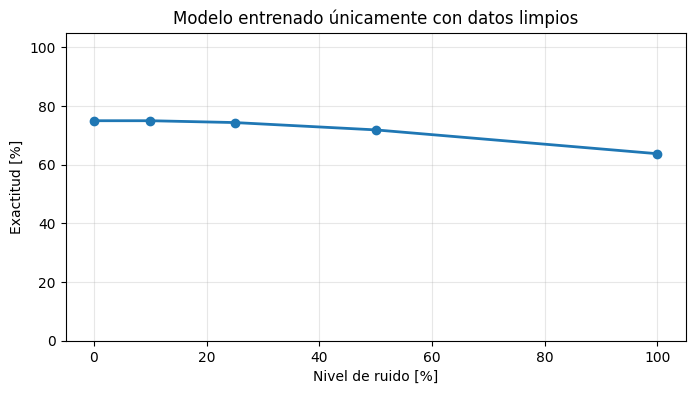

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(
    clean_model_results["Nivel de ruido"] * 100,
    clean_model_results["Exactitud"] * 100,
    marker="o",
    linewidth=2
)

plt.xlabel("Nivel de ruido [%]")
plt.ylabel("Exactitud [%]")
plt.title("Modelo entrenado únicamente con datos limpios")
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.show()


### 7.3 Entrenar con datos limpios y ruidosos

Crearemos varias copias de los datos de entrenamiento con diferentes niveles de ruido. El modelo aprenderá tanto de los datos originales como de sus versiones alteradas.


In [25]:
training_noise_levels = [0.10, 0.25, 0.50, 0.75]

X_augmented_parts = [X_final_train]
y_augmented_parts = [y_final_train]

for index, level in enumerate(training_noise_levels):
    X_noisy_copy = add_feature_noise(
        X_final_train,
        X_final_train,
        noise_fraction=level,
        seed=200 + index
    )

    X_augmented_parts.append(X_noisy_copy)
    y_augmented_parts.append(y_final_train)

X_train_augmented = pd.concat(
    X_augmented_parts,
    ignore_index=True
)

y_train_augmented = pd.concat(
    y_augmented_parts,
    ignore_index=True
)

robust_model = clone(models[best_model_name])
robust_model.fit(X_train_augmented, y_train_augmented)

print("Registros originales:", len(X_final_train))
print("Registros después de agregar ruido:", len(X_train_augmented))


Registros originales: 1280
Registros después de agregar ruido: 6400


### 7.4 Comparar ambos modelos

Evaluaremos el modelo original y el modelo entrenado con ruido usando exactamente los mismos datos de prueba.


In [26]:
comparison_results = []

for level in noise_levels:
    X_test_level = add_feature_noise(
        X_test,
        X_final_train,
        noise_fraction=level,
        seed=100
    )

    comparison_models = {
        "Entrenamiento limpio": final_model,
        "Entrenamiento con ruido": robust_model
    }

    for model_name, model in comparison_models.items():
        predictions = model.predict(X_test_level)

        comparison_results.append({
            "Modelo": model_name,
            "Nivel de ruido": level,
            "Exactitud": accuracy_score(y_test, predictions)
        })

noise_comparison = pd.DataFrame(comparison_results)

noise_comparison.assign(
    **{
        "Nivel de ruido": noise_comparison["Nivel de ruido"].map(
            lambda value: f"{value:.0%}"
        ),
        "Exactitud": noise_comparison["Exactitud"].map(
            lambda value: f"{value:.2%}"
        )
    }
)


,Modelo,Nivel de ruido,Exactitud
0,Entrenamiento limpio,0%,75.00%
1,Entrenamiento con ruido,0%,75.00%
2,Entrenamiento limpio,10%,75.00%
3,Entrenamiento con ruido,10%,75.00%
4,Entrenamiento limpio,25%,74.38%
5,Entrenamiento con ruido,25%,75.00%
6,Entrenamiento limpio,50%,71.88%
7,Entrenamiento con ruido,50%,74.69%
8,Entrenamiento limpio,100%,63.75%
9,Entrenamiento con ruido,100%,72.81%


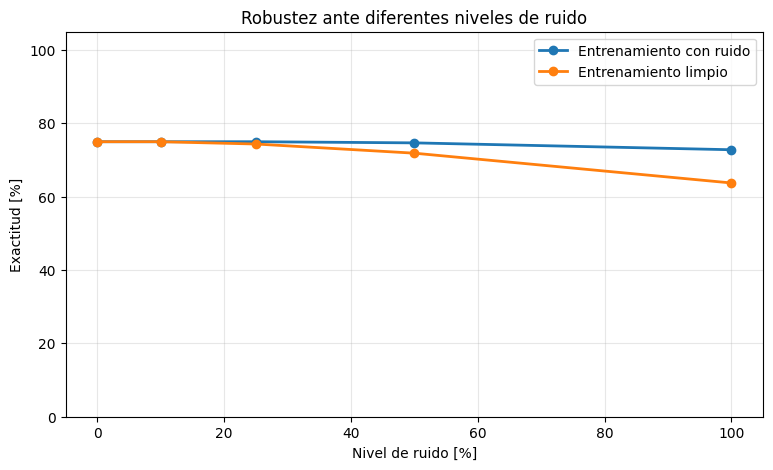

In [27]:
plt.figure(figsize=(9, 5))

for model_name, group in noise_comparison.groupby("Modelo"):
    plt.plot(
        group["Nivel de ruido"] * 100,
        group["Exactitud"] * 100,
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel("Nivel de ruido [%]")
plt.ylabel("Exactitud [%]")
plt.title("Robustez ante diferentes niveles de ruido")
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Actividad 5: ¿El entrenamiento con ruido ayuda?

Observen la tabla y las curvas:

1. ¿A partir de qué nivel de ruido cambia la exactitud?
2. ¿Cuál modelo conserva mejor su desempeño?
3. ¿El entrenamiento con ruido afecta la clasificación de los datos limpios?
4. Agreguen otro nivel de ruido y repitan el experimento.

Si la exactitud no cambia con ruido bajo, el modelo está siendo robusto ante esas pequeñas variaciones.

**Tiempo:** 10 minutos


## Cierre

Hoy seguimos el proceso completo: **observar señales → identificar patrones → extraer características → clasificar eventos → evaluar el efecto del ruido → mejorar la robustez del modelo**.

La inteligencia artificial no reemplaza el conocimiento del sistema eléctrico: permite utilizar las mediciones y características relevantes para analizar muchos eventos de forma consistente y rápida.
